In [1]:
from __future__ import annotations
from pathlib import Path
import sys
import argparse
import json

import pandas as pd
import scanpy as sc

PROCESSING_DIR = Path("~/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/Aaron/Xenium-functions-from-Alex").expanduser()
if str(PROCESSING_DIR) not in sys.path:
    sys.path.insert(0, str(PROCESSING_DIR))

from core_functions.processing_and_filtering import (
    add_placeholder_qc_metrics,
    plot_qc_feature,
    qc_before_clustering,
)

In [2]:

import seaborn as sns
from scipy import sparse
import numpy as np
import matplotlib.pyplot as plt


In [3]:
from pathlib import Path

def load_xenium_experiment(experiment_dir):
    experiment_dir = Path(experiment_dir).expanduser().resolve()

    if not experiment_dir.is_dir():
        raise FileNotFoundError(f"{experiment_dir} is not a valid directory")

    matrix_dirs = [
        path for path in experiment_dir.rglob("cell_feature_matrix")
        if path.is_dir()
    ]

    if not matrix_dirs and (experiment_dir / "cell_feature_matrix").is_dir():
        matrix_dirs = [experiment_dir / "cell_feature_matrix"]

    if len(matrix_dirs) == 0:
        raise FileNotFoundError(
            f"Could not find a cell_feature_matrix folder inside {experiment_dir}"
        )

    if len(matrix_dirs) > 1:
        raise ValueError(
            f"Found multiple cell_feature_matrix folders: {matrix_dirs}. "
            "Please pass one specific Xenium output directory."
        )

    cells_files = list(experiment_dir.rglob("cells.csv.gz"))
    if not cells_files:
        cells_files = list(experiment_dir.rglob("cells.csv"))

    if len(cells_files) == 0:
        raise FileNotFoundError(
            f"Could not find cells.csv.gz or cells.csv inside {experiment_dir}"
        )

    if len(cells_files) > 1:
        raise ValueError(
            f"Found multiple cells files: {cells_files}. "
            "Please pass one specific Xenium output directory."
        )

    matrix_dir = matrix_dirs[0]
    cells_file = cells_files[0]

    adata = sc.read_10x_mtx(matrix_dir)
    cells = pd.read_csv(cells_file, index_col=0)

    missing_cells = adata.obs_names[~adata.obs_names.isin(cells.index)]
    if len(missing_cells) > 0:
        raise ValueError(
            f"{cells_file.name} is missing metadata for {len(missing_cells)} cells, "
            f"for example: {missing_cells[:5].tolist()}"
        )

    adata.obs = cells.loc[adata.obs_names].copy()
    adata.uns["xenium_dir"] = str(experiment_dir)
    adata.uns["xenium_cells_file"] = str(cells_file)
    adata.uns["xenium_matrix_dir"] = str(matrix_dir)

    return adata


In [4]:
AD_inf_dir = "~/Library/CloudStorage/Box-Box/Kaech Lab Folder/MAIN LAB FOLDER (Ordering, lab meetings, protocols, IACUC)/Spatial transcriptomics datasets/20240627__192310__KAECH_AD_GBM_240627/output-XETG00224__0023902__APPPS1_infected_453f30__20240627__192344"
AD_mock_dir = "~/Library/CloudStorage/Box-Box/Kaech Lab Folder/MAIN LAB FOLDER (Ordering, lab meetings, protocols, IACUC)/Spatial transcriptomics datasets/20240627__192310__KAECH_AD_GBM_240627/output-XETG00224__0023902__APPPS1_mock_437f2__20240627__192344"
reference_ln_dir = "~/Library/CloudStorage/Box-Box/Kaech Lab Folder/MAIN LAB FOLDER (Ordering, lab meetings, protocols, IACUC)/Spatial transcriptomics datasets/20240627__192310__KAECH_AD_GBM_240627/output-XETG00224__0023902__REFERENCE_LN__20240627__192344"

AD_inf = load_xenium_experiment(AD_inf_dir)
AD_mock = load_xenium_experiment(AD_mock_dir)
reference_ln = load_xenium_experiment(reference_ln_dir)



In [5]:

AD_inf

AnnData object with n_obs × n_vars = 60392 × 480
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method'
    var: 'gene_ids', 'feature_types'
    uns: 'xenium_dir', 'xenium_cells_file', 'xenium_matrix_dir'

In [6]:
AD_mock

AnnData object with n_obs × n_vars = 72911 × 480
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method'
    var: 'gene_ids', 'feature_types'
    uns: 'xenium_dir', 'xenium_cells_file', 'xenium_matrix_dir'

In [7]:
reference_ln

AnnData object with n_obs × n_vars = 47258 × 480
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method'
    var: 'gene_ids', 'feature_types'
    uns: 'xenium_dir', 'xenium_cells_file', 'xenium_matrix_dir'

### QC and filtering

In [9]:
sc.pp.calculate_qc_metrics(AD_inf, percent_top=(10, 20, 50, 150), inplace=True)
sc.pp.calculate_qc_metrics(AD_mock, percent_top=(10, 20, 50, 150), inplace=True)
sc.pp.calculate_qc_metrics(reference_ln, percent_top=(10, 20, 50, 150), inplace=True)


In [10]:
def plot_cell_qc_metrics(
    adata,
    total_transcripts_threshold=(20, 1500),
    n_genes_threshold=(5, None),
    cell_area_threshold=(None, None),
    nucleus_ratio_threshold=(0, 1),
    nucleus_count_threshold=(1, 1),
    bins=60,
):
    """
    Plot 5 QC metrics from adata.obs and show threshold lines.

    Metrics:
      1. total transcripts per cell
      2. unique genes per cell
      3. segmented cell area
      4. nucleus area / cell area
      5. nucleus count
    """

    obs = adata.obs.copy()

    # Total transcripts
    if "total_transcripts" in obs.columns:
        total_transcripts = obs["total_transcripts"]
    elif "transcript_counts" in obs.columns:
        total_transcripts = obs["transcript_counts"]
    elif "total_counts" in obs.columns:
        total_transcripts = obs["total_counts"]
    else:
        total_transcripts = np.asarray(adata.X.sum(axis=1)).ravel()

    # Unique genes per cell
    if "n_genes_by_counts" in obs.columns:
        n_genes = obs["n_genes_by_counts"]
    else:
        if sparse.issparse(adata.X):
            n_genes = np.asarray((adata.X > 0).sum(axis=1)).ravel()
        else:
            n_genes = (adata.X > 0).sum(axis=1)

    qc_df = pd.DataFrame(index=adata.obs_names)
    qc_df["total_transcripts"] = pd.to_numeric(total_transcripts, errors="coerce")
    qc_df["n_genes_by_counts"] = pd.to_numeric(n_genes, errors="coerce")
    qc_df["cell_area"] = pd.to_numeric(obs["cell_area"], errors="coerce")
    qc_df["nucleus_ratio"] = (
        pd.to_numeric(obs["nucleus_area"], errors="coerce")
        / pd.to_numeric(obs["cell_area"], errors="coerce").replace(0, np.nan)
    )
    qc_df["nucleus_count"] = pd.to_numeric(obs["nucleus_count"], errors="coerce")

    metrics = {
        "total_transcripts": {
            "title": "Total transcripts per cell",
            "threshold": total_transcripts_threshold,
        },
        "n_genes_by_counts": {
            "title": "Unique genes per cell",
            "threshold": n_genes_threshold,
        },
        "cell_area": {
            "title": "Area of segmented cells",
            "threshold": cell_area_threshold,
        },
        "nucleus_ratio": {
            "title": "Nucleus area / cell area",
            "threshold": nucleus_ratio_threshold,
        },
        "nucleus_count": {
            "title": "Nucleus count",
            "threshold": nucleus_count_threshold,
        },
    }

    fig, axs = plt.subplots(1, 5, figsize=(20, 4))

    keep_mask = pd.Series(True, index=qc_df.index)

    for ax, (metric, info) in zip(axs, metrics.items()):
        values = qc_df[metric].dropna()
        min_thresh, max_thresh = info["threshold"]

        sns.histplot(values, kde=False, bins=bins, ax=ax)
        ax.set_title(info["title"])

        if min_thresh is not None:
            ax.axvline(min_thresh, color="red", linestyle="--", linewidth=1)
            keep_mask &= qc_df[metric] >= min_thresh

        if max_thresh is not None:
            ax.axvline(max_thresh, color="red", linestyle="--", linewidth=1)
            keep_mask &= qc_df[metric] <= max_thresh

    plt.tight_layout()
    plt.show()

    print(f"Cells before filtering: {adata.n_obs}")
    print(f"Cells passing all thresholds: {keep_mask.sum()}")
    print(f"Cells filtered out: {(~keep_mask).sum()}")

    return qc_df, keep_mask


def filter_adata_explicit(
    adata,
    min_total_transcripts=None,
    max_total_transcripts=None,
    min_n_genes=None,
    max_n_genes=None,
    min_cell_area=None,
    max_cell_area=None,
    min_nucleus_ratio=None,
    max_nucleus_ratio=None,
    min_nucleus_count=None,
    max_nucleus_count=None,
):
    """Filter an AnnData object according to explicit QC thresholds."""

    obs = adata.obs.copy()

    if "total_transcripts" in obs.columns:
        total_transcripts = pd.to_numeric(obs["total_transcripts"], errors="coerce")
    elif "transcript_counts" in obs.columns:
        total_transcripts = pd.to_numeric(obs["transcript_counts"], errors="coerce")
    elif "total_counts" in obs.columns:
        total_transcripts = pd.to_numeric(obs["total_counts"], errors="coerce")
    else:
        total_transcripts = np.asarray(adata.X.sum(axis=1)).ravel()
        total_transcripts = pd.to_numeric(total_transcripts, errors="coerce")

    if "n_genes_by_counts" in obs.columns:
        n_genes = pd.to_numeric(obs["n_genes_by_counts"], errors="coerce")
    else:
        if sparse.issparse(adata.X):
            n_genes = np.asarray((adata.X > 0).sum(axis=1)).ravel()
        else:
            n_genes = np.asarray((adata.X > 0).sum(axis=1))
        n_genes = pd.to_numeric(n_genes, errors="coerce")

    cell_area = pd.to_numeric(obs["cell_area"], errors="coerce") if "cell_area" in obs.columns else pd.Series(np.nan, index=adata.obs_names)

    if "nucleus_ratio" in obs.columns:
        nucleus_ratio = pd.to_numeric(obs["nucleus_ratio"], errors="coerce")
    elif "nucleus_area" in obs.columns and "cell_area" in obs.columns:
        nucleus_ratio = (
            pd.to_numeric(obs["nucleus_area"], errors="coerce")
            / pd.to_numeric(obs["cell_area"], errors="coerce").replace(0, np.nan)
        )
    else:
        nucleus_ratio = pd.Series(np.nan, index=adata.obs_names)

    nucleus_count = pd.to_numeric(obs["nucleus_count"], errors="coerce") if "nucleus_count" in obs.columns else pd.Series(np.nan, index=adata.obs_names)

    keep_mask = pd.Series(True, index=adata.obs_names)

    if min_total_transcripts is not None:
        keep_mask &= total_transcripts >= min_total_transcripts
    if max_total_transcripts is not None:
        keep_mask &= total_transcripts <= max_total_transcripts
    if min_n_genes is not None:
        keep_mask &= n_genes >= min_n_genes
    if max_n_genes is not None:
        keep_mask &= n_genes <= max_n_genes
    if min_cell_area is not None:
        keep_mask &= cell_area >= min_cell_area
    if max_cell_area is not None:
        keep_mask &= cell_area <= max_cell_area
    if min_nucleus_ratio is not None:
        keep_mask &= nucleus_ratio >= min_nucleus_ratio
    if max_nucleus_ratio is not None:
        keep_mask &= nucleus_ratio <= max_nucleus_ratio
    if min_nucleus_count is not None:
        keep_mask &= nucleus_count >= min_nucleus_count
    if max_nucleus_count is not None:
        keep_mask &= nucleus_count <= max_nucleus_count

    return adata[keep_mask.values].copy()


### QC on APPS/PS1 infected

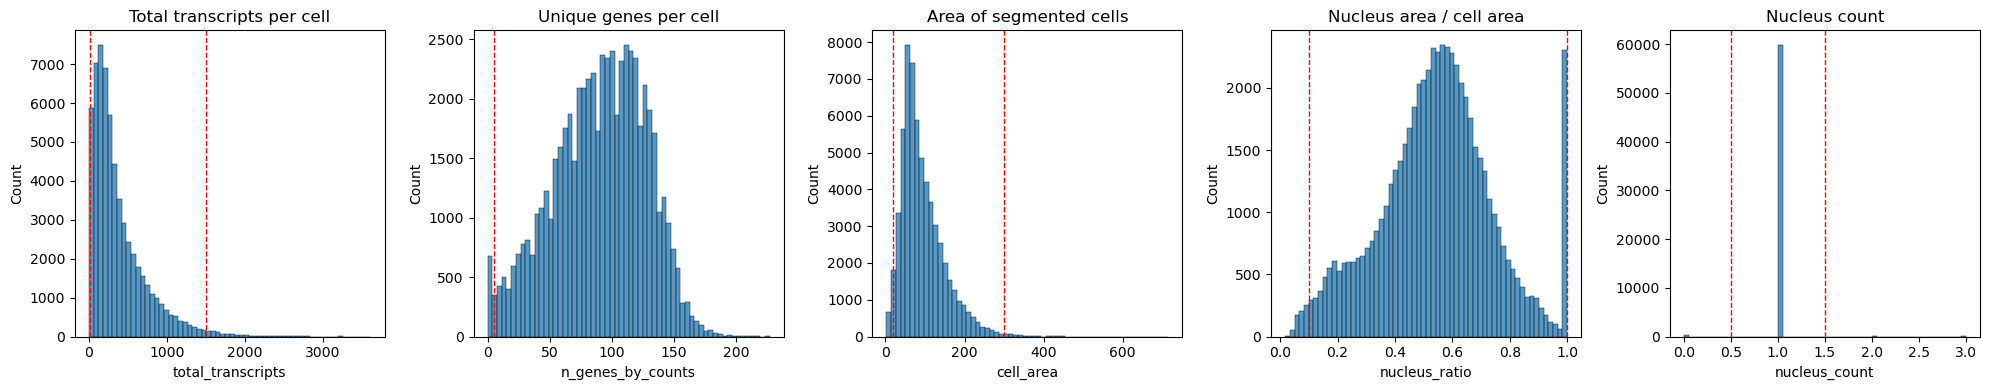

Cells before filtering: 60392
Cells passing all thresholds: 55615
Cells filtered out: 4777
Cells before filtering: 60392
Cells kept: 55615
Cells filtered out: 4777
Percent filtered out: 7.91%


In [11]:
qc_df, keep_mask = plot_cell_qc_metrics(
    AD_inf,
    total_transcripts_threshold=(20, 1500),
    n_genes_threshold=(5, None),
    cell_area_threshold=(20, 300),
    nucleus_ratio_threshold=(.1, 1),
    nucleus_count_threshold=(0.5, 1.5),
)

n_before = AD_inf.n_obs
n_after = keep_mask.sum()
n_filtered = n_before - n_after

print(f"Cells before filtering: {n_before}")
print(f"Cells kept: {n_after}")
print(f"Cells filtered out: {n_filtered}")
print(f"Percent filtered out: {n_filtered / n_before * 100:.2f}%")

### APPS/PS1 mock

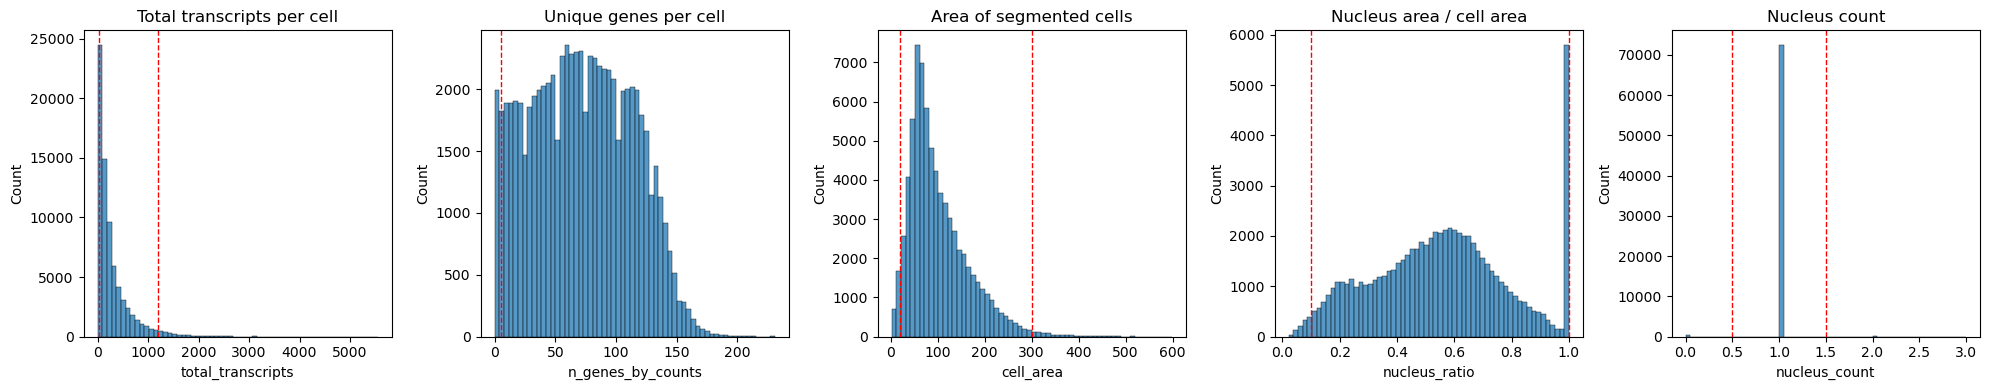

Cells before filtering: 72911
Cells passing all thresholds: 61347
Cells filtered out: 11564
Cells before filtering: 72911
Cells kept: 61347
Cells filtered out: 11564
Percent filtered out: 15.86%


In [12]:

qc_df, keep_mask = plot_cell_qc_metrics(
    AD_mock,
    total_transcripts_threshold=(20, 1200),
    n_genes_threshold=(5, None),
    cell_area_threshold=(20, 300),
    nucleus_ratio_threshold=(0.1, 1),
    nucleus_count_threshold=(0.5, 1.5),
)

n_before = AD_mock.n_obs
n_after = keep_mask.sum()
n_filtered = n_before - n_after

print(f"Cells before filtering: {n_before}")
print(f"Cells kept: {n_after}")
print(f"Cells filtered out: {n_filtered}")
print(f"Percent filtered out: {n_filtered / n_before * 100:.2f}%")

### QC Reference LN 

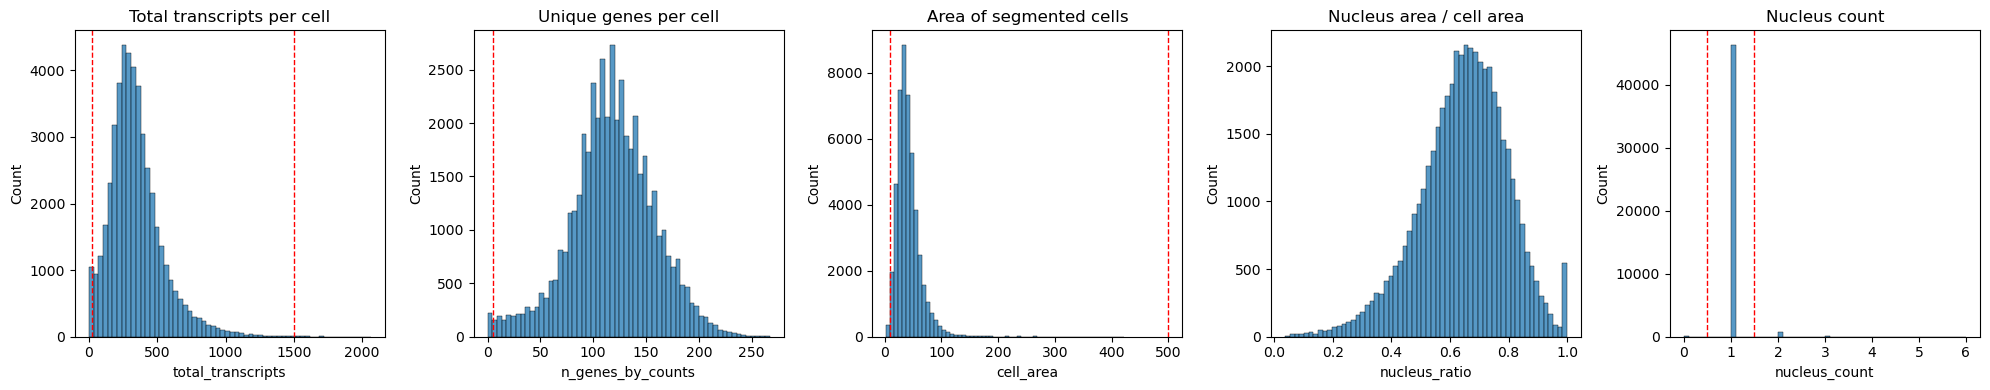

Cells before filtering: 47258
Cells passing all thresholds: 45458
Cells filtered out: 1800
Cells before filtering: 47258
Cells kept: 45458
Cells filtered out: 1800
Percent filtered out: 3.81%


In [13]:
qc_df, keep_mask = plot_cell_qc_metrics(
    reference_ln,
    total_transcripts_threshold=(20, 1500),
    n_genes_threshold=(5, None),
    cell_area_threshold=(10, 500),
    nucleus_ratio_threshold=(None, None),
    nucleus_count_threshold=(0.5, 1.5),
)

n_before = reference_ln.n_obs
n_after = keep_mask.sum()
n_filtered = n_before - n_after

print(f"Cells before filtering: {n_before}")
print(f"Cells kept: {n_after}")
print(f"Cells filtered out: {n_filtered}")
print(f"Percent filtered out: {n_filtered / n_before * 100:.2f}%")

### Filtering the data now

In [14]:

def filter_adata_explicit(
    adata,
    min_total_transcripts=20,
    max_total_transcripts=1700,
    min_n_genes=5,
    max_n_genes=None,
    min_cell_area=10,
    max_cell_area=500,
    min_nucleus_ratio=0,
    max_nucleus_ratio=1,
    min_nucleus_count=0.5,
    max_nucleus_count=1.5,
):
    """Filter AnnData cells by explicit QC thresholds."""

    obs = adata.obs.copy()

    if "total_transcripts" in obs.columns:
        total_transcripts = pd.to_numeric(obs["total_transcripts"], errors="coerce")
    elif "transcript_counts" in obs.columns:
        total_transcripts = pd.to_numeric(obs["transcript_counts"], errors="coerce")
    elif "total_counts" in obs.columns:
        total_transcripts = pd.to_numeric(obs["total_counts"], errors="coerce")
    else:
        total_transcripts = pd.to_numeric(np.asarray(adata.X.sum(axis=1)).ravel(), errors="coerce")

    if "n_genes_by_counts" in obs.columns:
        n_genes = pd.to_numeric(obs["n_genes_by_counts"], errors="coerce")
    else:
        if sparse.issparse(adata.X):
            n_genes = np.asarray((adata.X > 0).sum(axis=1)).ravel()
        else:
            n_genes = np.asarray((adata.X > 0).sum(axis=1))
        n_genes = pd.to_numeric(n_genes, errors="coerce")

    cell_area = (
        pd.to_numeric(obs["cell_area"], errors="coerce")
        if "cell_area" in obs.columns
        else pd.Series(np.nan, index=adata.obs_names)
    )

    if "nucleus_ratio" in obs.columns:
        nucleus_ratio = pd.to_numeric(obs["nucleus_ratio"], errors="coerce")
    elif "nucleus_area" in obs.columns and "cell_area" in obs.columns:
        nucleus_ratio = (
            pd.to_numeric(obs["nucleus_area"], errors="coerce")
            / pd.to_numeric(obs["cell_area"], errors="coerce").replace(0, np.nan)
        )
    else:
        nucleus_ratio = pd.Series(np.nan, index=adata.obs_names)

    nucleus_count = (
        pd.to_numeric(obs["nucleus_count"], errors="coerce")
        if "nucleus_count" in obs.columns
        else pd.Series(np.nan, index=adata.obs_names)
    )

    keep = pd.Series(True, index=adata.obs_names)

    keep &= total_transcripts >= min_total_transcripts
    keep &= total_transcripts <= max_total_transcripts
    keep &= n_genes >= min_n_genes
    if max_n_genes is not None:
        keep &= n_genes <= max_n_genes
    keep &= cell_area >= min_cell_area
    keep &= cell_area <= max_cell_area
    keep &= nucleus_ratio >= min_nucleus_ratio
    keep &= nucleus_ratio <= max_nucleus_ratio
    keep &= nucleus_count >= min_nucleus_count
    keep &= nucleus_count <= max_nucleus_count

    return adata[keep.values].copy()

In [15]:
AD_inf_filtered = filter_adata_explicit(
    AD_inf,
    min_total_transcripts=20,
    max_total_transcripts=1700,
    min_n_genes=5,
    min_cell_area=10,
    max_cell_area=500,
    min_nucleus_ratio=0,
    max_nucleus_ratio=1,
    min_nucleus_count=0.5,
    max_nucleus_count=1.5,
)

AD_mock_filtered = filter_adata_explicit(
    AD_mock,
    min_total_transcripts=20,
    max_total_transcripts=1700,
    min_n_genes=5,
    min_cell_area=10,
    max_cell_area=500,
    min_nucleus_ratio=0,
    max_nucleus_ratio=1,
    min_nucleus_count=0.5,
    max_nucleus_count=1.5,
)

reference_ln_filtered = filter_adata_explicit(
    reference_ln,
    min_total_transcripts=20,
    max_total_transcripts=1700,
    min_n_genes=5,
    min_cell_area=10,
    max_cell_area=500,
    min_nucleus_ratio=0,
    max_nucleus_ratio=1,
    min_nucleus_count=0.5,
    max_nucleus_count=1.5,
)


In [17]:
save_dir = Path("~/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/Python Objects h5ad/").expanduser()
save_dir.mkdir(parents=True, exist_ok=True)

AD_inf_filtered.write_h5ad(save_dir / "AD_inf_filtered.h5ad")
AD_mock_filtered.write_h5ad(save_dir / "AD_mock_filtered.h5ad")
reference_ln_filtered.write_h5ad(save_dir / "reference_ln_filtered.h5ad")
